In [79]:
import numpy as np
import pandas as pd

In [80]:
df = pd.read_csv("train.csv")

In [81]:
df.shape

(42000, 785)

In [82]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [84]:
import matplotlib.pyplot as plt

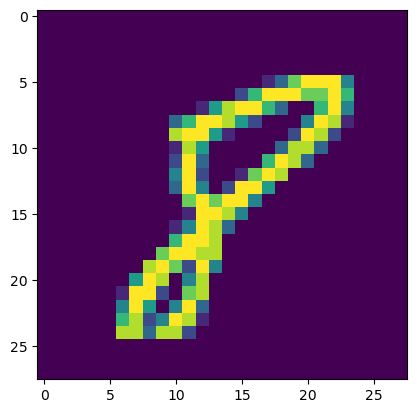

In [85]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

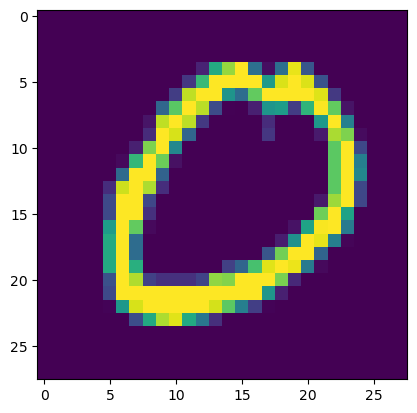

In [86]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [87]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [88]:
x

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [89]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [92]:
x_train.shape

(33600, 784)

In [93]:
from sklearn.neighbors import KNeighborsClassifier

In [94]:
knn = KNeighborsClassifier()

In [95]:
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [96]:
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)

19.250582695007324


In [97]:
y_pred.shape

(8400,)

In [98]:
y_test.shape

(8400,)

In [99]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [100]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [106]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [107]:
from sklearn.decomposition import PCA

In [108]:
pca = PCA(n_components=None)

In [111]:
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

In [112]:
x_train.shape

(33600, 784)

In [113]:
pca = PCA(n_components=100)

In [117]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [118]:
x_train.shape

(33600, 100)

In [116]:
knn = KNeighborsClassifier()

In [119]:
knn.fit(x_train_trf,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [124]:
y_pred = knn.predict(x_train_trf)